## Examine the input files

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

import scanpy as sc
import muon as mu

REPO_ROOT = os.getcwd()
print("REPO_ROOT:", REPO_ROOT)


def _matrix_summary(x, label, quantiles=(0.0, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0)):
    if sparse.issparse(x):
        n_obs, n_vars = x.shape
        total = n_obs * n_vars
        nnz = int(x.nnz)
        nonzero = np.asarray(x.data, dtype=np.float64)
        zero_fraction = 1.0 - (nnz / total if total else 0.0)
        min_value = float(x.min()) if total else float("nan")
        max_value = float(x.max()) if total else float("nan")
        mean_value = float(x.mean()) if total else float("nan")
        if total:
            sum_sq = float(x.multiply(x).sum())
            std_value = float(np.sqrt(max(sum_sq / total - mean_value ** 2, 0.0)))
        else:
            std_value = float("nan")
    else:
        arr = np.asarray(x, dtype=np.float64)
        n_obs, n_vars = arr.shape
        total = arr.size
        nonzero = arr[arr != 0].ravel()
        zero_fraction = float(np.mean(arr == 0)) if total else float("nan")
        min_value = float(arr.min()) if total else float("nan")
        max_value = float(arr.max()) if total else float("nan")
        mean_value = float(arr.mean()) if total else float("nan")
        std_value = float(arr.std()) if total else float("nan")

    if nonzero.size:
        nz_quantiles = np.quantile(nonzero, quantiles)
    else:
        nz_quantiles = np.full(len(quantiles), np.nan)

    summary = {
        "label": label,
        "n_obs": int(n_obs),
        "n_vars": int(n_vars),
        "nnz": int(nonzero.size),
        "zero_fraction": float(zero_fraction),
        "min": min_value,
        "max": max_value,
        "mean": mean_value,
        "std": std_value,
    }
    for q, value in zip(quantiles, nz_quantiles):
        summary[f"nonzero_q{q:g}"] = float(value)
    return summary


def _sample_values(x, max_points=100000, include_zeros=True, seed=0):
    rng = np.random.default_rng(seed)
    if sparse.issparse(x):
        dense = x.toarray().ravel() if include_zeros else np.asarray(x.data)
    else:
        dense = np.asarray(x).ravel()
        if not include_zeros:
            dense = dense[dense != 0]
    if dense.size == 0:
        return dense
    if dense.size > max_points:
        idx = rng.choice(dense.size, size=max_points, replace=False)
        dense = dense[idx]
    return np.asarray(dense, dtype=np.float64)


def inspect_adata(adata, label, group_key=None):
    print(f"=== {label} ===")
    print(adata)
    print("X type:", type(adata.X))
    print("obs columns:", list(adata.obs.columns))
    print("var_names head:", adata.var_names[:10].tolist())
    if group_key is not None and group_key in adata.obs:
        print(f"{group_key} distribution:")
        print(adata.obs[group_key].value_counts(dropna=False).sort_index())
    summary = _matrix_summary(adata.X, label)
    display(pd.DataFrame([summary]).T.rename(columns={0: label}))

    sampled_all = _sample_values(adata.X, include_zeros=True, seed=0)
    sampled_nz = _sample_values(adata.X, include_zeros=False, seed=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(sampled_all, bins=100, color="#4C78A8", alpha=0.85)
    axes[0].set_title(f"{label}: sampled values (including zeros)")
    axes[0].set_xlabel("Expression value")
    axes[0].set_ylabel("Count")

    if sampled_nz.size:
        axes[1].hist(sampled_nz, bins=100, color="#F58518", alpha=0.85)
        axes[1].set_title(f"{label}: nonzero values only")
    else:
        axes[1].text(0.5, 0.5, "No nonzero entries", ha="center", va="center")
        axes[1].set_title(f"{label}: nonzero values only")
    axes[1].set_xlabel("Expression value")
    axes[1].set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    return summary


/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REPO_ROOT: /home/anniehuang/Squidiff


/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
print(REPO_ROOT)

/home/anniehuang/Squidiff


Mouse file exists: True
Mouse path: /home/anniehuang/Squidiff/data/mouse/processed/mouse_train.h5mu


/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/anniehuang/anaconda3/envs/omics/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 9358 × 69575
  var:	'interval'
  uns:	'stage_to_group'
  2 modalities
    rna:	9358 × 2810
      obs:	'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'hvg'
      layers:	'counts'
    atac:	9358 × 66765
      obs:	'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
      var:	'interval', 'chrom', 'start', 'end'
      layers:	'counts'
Available modalities: ['rna', 'atac']
=== Mouse RNA train ===
AnnData object with n_obs × n_vars = 9358 × 2810
    obs: 'stage', 'replicate', 'Group', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch_stage'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'highly_variable', 'means', 'dispersions', 'disp

,Mouse RNA train
label,Mouse RNA train
n_obs,9358
n_vars,2810
nnz,3909684
zero_fraction,0.85132
min,0.0
max,8.065309
mean,0.196478
std,0.545761
nonzero_q0,0.288225


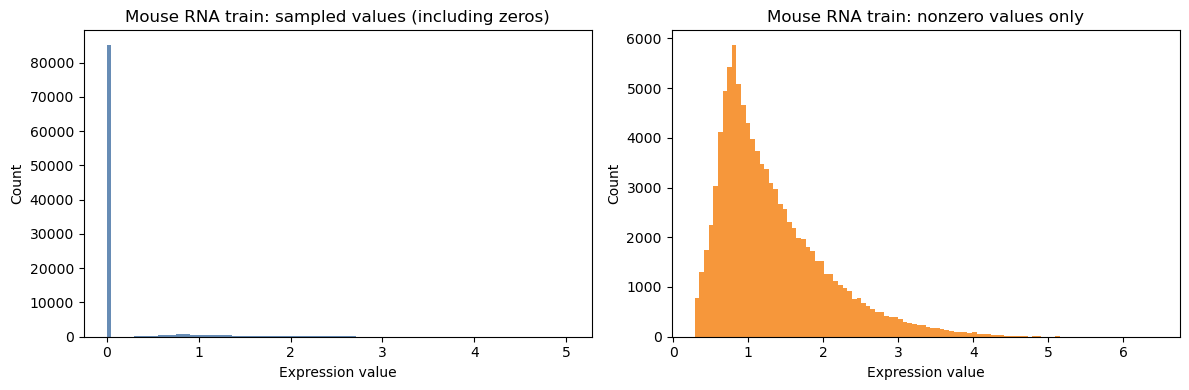

In [4]:
# Load mouse data (multi-omics, inspect RNA only)
mouse_fn = os.path.join(REPO_ROOT, 'data', 'mouse', 'processed', 'mouse_train.h5mu')
print('Mouse file exists:', os.path.exists(mouse_fn))
print('Mouse path:', mouse_fn)

mouse_mdata = mu.read_h5mu(mouse_fn)
print(mouse_mdata)
print('Available modalities:', list(mouse_mdata.mod.keys()))

mouse_rna = mouse_mdata['rna']
mouse_summary = inspect_adata(mouse_rna, label='Mouse RNA train', group_key='Group')


In [ ]:
# Compare the two datasets side by side
comparison = pd.DataFrame([ipsc_summary, mouse_summary]).set_index('label').T
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for values, color, label in [
    (_sample_values(ipsc_adata.X, include_zeros=False, seed=2), '#4C78A8', 'iPSC train'),
    (_sample_values(mouse_rna.X, include_zeros=False, seed=3), '#E45756', 'Mouse RNA train'),
]:
    axes[0].hist(values, bins=100, density=True, histtype='step', linewidth=2, color=color, label=label)
axes[0].set_title('Nonzero expression distribution')
axes[0].set_xlabel('Expression value')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].bar(['iPSC train', 'Mouse RNA train'], [ipsc_summary['zero_fraction'], mouse_summary['zero_fraction']], color=['#4C78A8', '#E45756'])
axes[1].set_title('Zero fraction')
axes[1].set_ylabel('Fraction of zeros')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
